In [8]:
import numpy as np
import pandas as pd

import geopy
from geopy.geocoders import Nominatim

from math import radians, cos, sin, asin, sqrt
import googlemaps
from datetime import datetime

import json

# Cleaning Data

In [3]:
yerevan_actual_raw = pd.read_excel('./data/Yerevan actual.xlsx')

## filtering out duplicated in id 

In [67]:
yerevan_actual_raw = yerevan_actual_raw.drop(["OBJECTID", "level_0", "index"], axis = 1)
duplicates = yerevan_actual_raw.duplicated(subset=['id'])
yerevan_actual = yerevan_actual_raw[~duplicates].drop_duplicates(subset=['id'])
yerevan_actual = yerevan_actual.reset_index()

## Ceategorizing Regions

In [ ]:
data = yerevan_actual.copy()

In [ ]:
geolocator = Nominatim(user_agent="my_application")

count = 0
yerevan_districts = pd.DataFrame(columns=['x', 'y', 'district'])

import pandas as pd

# Create an empty DataFrame to store the results


def get_district(lat, lng):
    # Reverse geocode the coordinates to get the address
    location = geolocator.reverse(f"{lat}, {lng}", timeout=None)
    # Extract the district information from the address
    address = location.raw['address']
    district = address.get('suburb', address.get('city_district'))
    return district

# Loop through each row of the data and calculate the district for each row
# for i, row in data.iterrows():
#     # Calculate the district for the current row
#     district = get_district(row['x'], row['y'])
#     count = count + 1
#     data.drop(index=data.index[0], axis=0, inplace=True)
#     # Append the current row to the new DataFrame
#     yerevan_districts = yerevan_districts.append({'x': row['x'], 'y': row['y'], 'district': district}, ignore_index=True)

In [ ]:
# Save the results to a CSV file
# yerevan_actual["district"] = yerevan_districts["district"]
# yerevan_actual.to_excel("Yerevan.xlsx", index=False)

In [5]:
yerevan_actual = pd.read_excel('./data/Yerevan.xlsx')

## Metro Distance Calculation

In [ ]:
h1 = pd.read_excel('./data/Yerevan.xlsx')
houses = h1.copy() # houses is used for testing

# Load the houses and stations tables into pandas dataframes

stations = pd.DataFrame({
    'station_id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'station_name': ['Barekamutyun', 'Baghramyan', 'Yeritasardakan', 'Republic Square', 'Zoravar Andranik', 'Sasuntsi Davit', 'Gortsaranain','Shengavit', 'Charbakh', 'Garegin Nzhdeh Square'],
    'x': [40.197446,40.1918167,40.1873081, 40.1785331, 40.1699272, 40.1552243, 40.1410611, 40.145224, 40.1405941, 40.1504761],
    'y': [44.493467,44.5038091, 44.5191743, 44.5134433, 44.5112603, 44.5058011, 44.4964173, 44.48483, 44.4685333, 44.4816183]
})

In [ ]:
# Define a function to calculate the Haversine distance between two points
def haversine(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance between two points 
    on the earth (specified in decimal degrees)
    """
    # Convert decimal degrees to radians 
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])

    # Haversine formula 
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a)) 
    r = 6371 # Radius of earth in kilometers. Use 3956 for miles
    return c * r

def get_walking_distance(start_lon, start_lat, end_lon, end_lat):
    # Set up the Google Maps API client
    gmaps = googlemaps.Client(key='***REMOVED-GOOGLE-API-KEY***')

    # Define the start and end coordinates
    start = (start_lat, start_lon)
    end = (end_lat, end_lon)

    # Make the API request
    now = datetime.now()
    directions = gmaps.directions(start, end, mode='walking', departure_time=now)

    # Extract the distance from the response
    distance = directions[0]['legs'][0]['distance']['value']

    # Return the distance in meters
    return distance

#### calculating distance from every house to every metro station and taking shortest path

In [ ]:
# Loop through each house and station to find the shortest distance using Haversine
#distances = []
# station_ids = []
# station_names = []
# for house_idx, house in houses.iterrows():
#     shortest_distance = float('inf')
#     nearest_station_name = ''
#     for station_idx, station in stations.iterrows():
#         distance = haversine(house['y'], house['x'], station['y'], station['x'])
#         if distance < shortest_distance:
#             shortest_distance = distance
#             nearest_station_id = station['station_id']
#             nearest_station_name = station['station_name']
#     #distances.append(shortest_distance)
#     station_ids.append(nearest_station_id)
#     station_names.append(nearest_station_name)

# # Add the new columns to the houses table
# #houses['shortest_distance'] = distances
# houses['nearest_station_id'] = station_ids
# houses['nearest_station_name'] = station_names
# houses

#### we have closest metro station using haversine distance, now we calculate the walking distance
The code runs for around 4-5 hours so it is commented out

In [19]:
# h1["closest_metro"] = houses["nearest_station_name"]
# distances = []

# # Using Google Maps API to calculate the walking distance
# for i, house in houses.iterrows():
#     distance = get_walking_distance(house['y'], house['x'], stations['y'][house['nearest_station_id']-1], stations['x'][house['nearest_station_id']-1])
#     distances.append(distance)
#     houses.drop(index=houses.index[0], axis=0, inplace=True)
# #houses["walk_distance"] = distances

# h1["walking_distance_to_metro(m)"] = distances

# Overwriting Yervan.xlsx file with the new metro and walking distance columns
# h1.to_excel("Yerevan.xlsx", index=False)

In [37]:
yerevan_actual = pd.read_excel('./data/Yerevan.xlsx')

### rent and sales real-estate

In [23]:
sale = yerevan_actual.loc[(yerevan_actual["rent_or_sale"]=="sale appartments") | (yerevan_actual["rent_or_sale"]=="sale houses")]
rent = yerevan_actual.loc[(yerevan_actual["rent_or_sale"]=="rent houses") | (yerevan_actual["rent_or_sale"]=="rent appartments")]

## filtering null values

In [42]:
house_filtered = yerevan_actual.dropna()

In [113]:
houses_filt = yerevan_actual.dropna(subset=['price'])

In [114]:
houses_filt.isnull().sum()

index                              0
id                                 0
price                              0
rooms                            718
square_meters                      2
address                            0
date                               0
source                             0
furniture                          0
renovation                      4130
price_per_meter                    3
floor                           4442
building_floors                  586
height                          4086
bathroom                         220
rent_or_sale                       0
links                              0
y                                  0
x                                  0
district                          16
closest_metro                      0
walking_distance_to_metro(m)       0
dtype: int64

In [112]:
house_filtered.isnull().sum()

index                           0
id                              0
price                           0
rooms                           0
square_meters                   0
address                         0
date                            0
source                          0
furniture                       0
renovation                      0
price_per_meter                 0
floor                           0
building_floors                 0
height                          0
bathroom                        0
rent_or_sale                    0
links                           0
y                               0
x                               0
district                        0
closest_metro                   0
walking_distance_to_metro(m)    0
dtype: int64

# outlier detection according to districts and rent_or_sale

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

In [115]:
# price null values are gone
# sale = houses_filt.loc[(houses_filt["rent_or_sale"]=="sale appartments") | (houses_filt["rent_or_sale"]=="sale houses")]
# rent = houses_filt.loc[(houses_filt["rent_or_sale"]=="rent houses") | (houses_filt["rent_or_sale"]=="rent appartments")]

In [137]:
# all null values are gone
sale = house_filtered.loc[(house_filtered["rent_or_sale"]=="sale appartments") | (house_filtered["rent_or_sale"]=="sale houses")]
rent = house_filtered.loc[(house_filtered["rent_or_sale"]=="rent houses") | (house_filtered["rent_or_sale"]=="rent appartments")]

In [138]:
armenian_to_english = {'Աջափնյակ': 'Achapnyak',
                       'Նոր Նորք': 'Nor-Nork',
                       'Արաբկիր': 'Arabkir',
                       'Կենտրոն': 'Kentron',
                       'Դավթաշեն': 'Davtashen',
                       'Էրեբունի': 'Erebuni',
                       'Շենգավիթ': 'Shengavit',
                       'Քանաքեռ-Զեյթուն': 'Qanaqer-Zeytun',
                       'Մալաթիա-Սեբաստիա': 'Malatia-Sebastia',
                       'Ավան': 'Avan',
                       'Նոր Նորքի 1-ին զանգված': 'Nor-Nork',
                       'Նոր Նորքի 2-րդ զանգված': 'Nor-Nork',
                       'Դավթաշեն գյուղ': 'Davtashen',
                       'Նորք Մարաշ': 'Norq-Marash',
                       'Գլենդել Հիլզ': 'Kentron',
                       'Նուբարաշեն': 'Nubarashen'}

sale['district'] = sale['district'].replace(armenian_to_english)

/var/folders/31/mgjvydd530n_q8xd9pnv0wrc0000gq/T/ipykernel_49850/1185843019.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sale['district'] = sale['district'].replace(armenian_to_english)


,index,id,price,rooms,square_meters,address,date,source,furniture,renovation,...,building_floors,height,bathroom,rent_or_sale,links,y,x,district,closest_metro,walking_distance_to_metro(m)
0,0,19136358,113000.0,2.0,55.0,"Աբելյան փողոց 22, Երևան",2023-03-13 18:58:27,list.am,0,No Renovation,...,10,3.00,1.0,sale appartments,http://list.am/en/item/19136358,44.472724,40.198827,Achapnyak,Barekamutyun,2929
1,1,18934317,162000.0,3.0,90.0,"Lvovyan street 14, Yerevan",2023-03-13 18:58:28,list.am,0,Designer Renovation,...,7,3.00,1.0,sale appartments,http://list.am/en/item/18934317,44.562313,40.203270,Nor-Nork,Yeritasardakan,6706
2,2,19112565,35200.0,1.0,20.0,"Կոմիտասի պողոտա, Երևան",2023-03-13 18:58:28,list.am,0,Cosmetic Renovation,...,5,2.75,1.0,sale appartments,http://list.am/en/item/19112565,44.507210,40.206239,Arabkir,Barekamutyun,1677
3,3,19061447,68999.0,1.0,42.0,"Khorenatsi street, Yerevan",2023-03-13 18:58:28,list.am,0,Cosmetic Renovation,...,9,2.75,1.0,sale appartments,http://list.am/en/item/19061447,44.515008,40.165975,Kentron,Zoravar Andranik,722
4,4,18995093,90000.0,2.0,50.0,"Komitas avenu 49, Երևան",2023-03-13 18:58:29,list.am,0,Euro Renovation,...,7,2.80,1.0,sale appartments,http://list.am/en/item/18995093,44.515673,40.206955,Arabkir,Baghramyan,2800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18529,20220,18924003,125000.0,3.0,83.0,"Davidashen 2-nd block, Yerevan",2023-03-13 21:06:45,list.am,0,Major Renovation,...,12,2.80,1.0,sale appartments,http://list.am/en/item/18924003,44.495065,40.225053,Davtashen,Barekamutyun,4008
18530,20229,18928456,159000.0,2.0,71.0,"Անաստաս Միկոյան փողոց, Երևան",2023-03-13 21:06:48,list.am,0,Euro Renovation,...,12,3.00,1.0,sale appartments,http://list.am/en/item/18928456,44.502036,40.221066,Davtashen,Barekamutyun,4221
18531,20230,18924917,62000.0,1.0,55.0,"Romanos Meliqyan street, Yerevan",2023-03-13 21:06:49,list.am,0,Major Renovation,...,9,2.80,1.0,sale appartments,http://list.am/en/item/18924917,44.549800,40.230135,Qanaqer-Zeytun,Yeritasardakan,7554
18532,20231,15550437,75000.0,2.0,55.0,"Улица Башинджагяна, Yerevan",2023-03-13 21:06:49,list.am,0,Cosmetic Renovation,...,5,2.80,2.0,sale appartments,http://list.am/en/item/15550437,44.468664,40.200880,Achapnyak,Barekamutyun,3505


### Box-Plot

(0.0, 2000000.0)

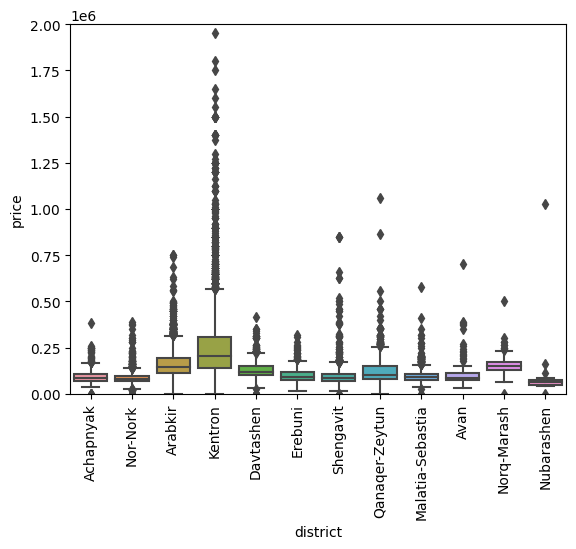

In [139]:
sns.boxplot(x='district', y='price', data=sale)
plt.xticks(rotation=90)
plt.ylim(0, 2000000)

### Z-Score

In [140]:
from scipy import stats

# read in the data
#df = pd.read_csv('data.csv')

# group the data by district
grouped_data = sale.groupby('district')

# loop over each group and calculate the Z-score for price
for name, group in grouped_data:
   # print(group["district"])
    z = np.abs(stats.zscore(group['price']))
    #print(z)
    threshold = 3
    outliers = group[z > threshold]
    
    num_outliers = len(outliers)
    print(f"District {name} has {num_outliers} outliers")

District Achapnyak has 15 outliers
District Arabkir has 49 outliers
District Avan has 7 outliers
District Davtashen has 15 outliers
District Erebuni has 10 outliers
District Kentron has 23 outliers
District Malatia-Sebastia has 14 outliers
District Nor-Nork has 20 outliers
District Norq-Marash has 1 outliers
District Nubarashen has 1 outliers
District Qanaqer-Zeytun has 14 outliers
District Shengavit has 27 outliers


### IQR

In [141]:
for name, group in grouped_data:
    q1 = group['price'].quantile(0.25)
    #print(q1)
    q3 = group['price'].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = group[(group['price'] < lower_bound) | (group['price'] > upper_bound)]
    num_outliers = len(outliers)
    print(f"District {name} has {num_outliers} outliers")

District Achapnyak has 35 outliers
District Arabkir has 174 outliers
District Avan has 17 outliers
District Davtashen has 57 outliers
District Erebuni has 23 outliers
District Kentron has 287 outliers
District Malatia-Sebastia has 79 outliers
District Nor-Nork has 89 outliers
District Norq-Marash has 11 outliers
District Nubarashen has 4 outliers
District Qanaqer-Zeytun has 62 outliers
District Shengavit has 83 outliers


### Mahalanobis distance

In [142]:
from sklearn.covariance import MinCovDet
from scipy.spatial.distance import mahalanobis

# loop over each group and calculate the Mahalanobis distance
dfs_to_concat = []
grouped_data = sale.groupby('district')
for name, group in grouped_data:
    X = group[['price', 'square_meters']]
    covariance = np.cov(X, rowvar=False)
    mahal = np.apply_along_axis(lambda x: mahalanobis(x, X.mean(axis=0), np.linalg.inv(covariance)), 1, X)
    threshold = 3
    outliers = group[np.array(mahal) > threshold]
    num_outliers = len(outliers)
    print(f"District {name} has {num_outliers} outliers:")
    #print(outliers)
    filtered_group = group[np.array(mahal) <= threshold]
    dfs_to_concat.append(filtered_group)

# concatenate the filtered DataFrames back together
filtered_df = pd.concat(dfs_to_concat, ignore_index=True)

District Achapnyak has 36 outliers:
District Arabkir has 108 outliers:
District Avan has 13 outliers:
District Davtashen has 37 outliers:
District Erebuni has 17 outliers:
District Kentron has 124 outliers:
District Malatia-Sebastia has 53 outliers:
District Nor-Nork has 33 outliers:
District Norq-Marash has 2 outliers:
District Nubarashen has 1 outliers:
District Qanaqer-Zeytun has 22 outliers:
District Shengavit has 38 outliers:


In [143]:
filtered_df

,index,id,price,rooms,square_meters,address,date,source,furniture,renovation,...,building_floors,height,bathroom,rent_or_sale,links,y,x,district,closest_metro,walking_distance_to_metro(m)
0,0,19136358,113000.000000,2.0,55.0,"Աբելյան փողոց 22, Երևան",2023-03-13 18:58:27,list.am,0,No Renovation,...,10,3.00,1.0,sale appartments,http://list.am/en/item/19136358,44.472724,40.198827,Achapnyak,Barekamutyun,2929
1,11,18851985,90000.000000,3.0,70.0,"Shinararneri street, Yerevan",2023-03-13 18:58:32,list.am,0,Major Renovation,...,4,2.75,1.0,sale appartments,http://list.am/en/item/18851985,44.473874,40.195080,Achapnyak,Barekamutyun,2415
2,58,18958235,53000.000000,1.0,32.0,"Halabyan Street, Yerevan",2023-03-13 18:58:50,list.am,0,Cosmetic Renovation,...,4,2.60,1.0,sale appartments,http://list.am/en/item/18958235,44.479641,40.200088,Achapnyak,Barekamutyun,2586
3,61,18905814,132000.000000,4.0,102.0,"Bashinjaghyan street 1-st lane, Yerevan",2023-03-13 18:58:51,list.am,0,Major Renovation,...,5,2.75,2.0,sale appartments,http://list.am/en/item/18905814,44.467658,40.205199,Achapnyak,Barekamutyun,4068
4,85,18923005,68000.000000,2.0,65.0,"Lukashin street, Yerevan",2023-03-13 18:59:00,list.am,0,Old Renovation,...,5,2.75,1.0,sale appartments,http://list.am/en/item/18923005,44.453904,40.194350,Achapnyak,Barekamutyun,4457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16383,20155,18866953,67000.000000,1.0,30.0,"Yeghbayrutyan Street, Yerevan",2023-03-13 21:06:18,list.am,0,Major Renovation,...,4,2.75,1.0,sale appartments,http://list.am/en/item/18866953,44.483441,40.152390,Shengavit,Garegin Nzhdeh Square,271
16384,20169,19102347,74000.000000,2.0,62.0,"Bagratunyats Avenue, Yerevan",2023-03-13 21:06:24,list.am,0,Old Renovation,...,9,2.75,1.0,sale appartments,http://list.am/en/item/19102347,44.482210,40.151880,Shengavit,Garegin Nzhdeh Square,194
16385,20183,19046421,103000.000000,4.0,93.0,"Չեխովի փողոց, Երևան",2023-03-13 21:06:30,list.am,0,Cosmetic Renovation,...,5,2.80,1.0,sale appartments,http://list.am/en/item/19046421,44.479875,40.152515,Shengavit,Garegin Nzhdeh Square,313
16386,20189,19062133,115000.000000,2.0,65.0,"Աթոյան փողոց, Երևան",2023-03-13 21:06:33,list.am,0,Major Renovation,...,9,2.75,1.0,sale appartments,http://list.am/en/item/19062133,44.464576,40.142870,Shengavit,Charbakh,493


In [144]:
sale.to_excel(r'./data/sale.xlsx', index=False)
#rent.to_excel(r'./data/rent.xlsx', index=False)